In [1]:
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [2]:
from enum import auto
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft, iirfilter
from scipy.fft import fft, fftfreq, fftshift, ifft, rfft, rfftfreq, irfft
import math

In [3]:
def transform(file_name):
    sample_rate, data = wavfile.read(file_name)
    #TBD, split mono/stereo
    left_data = data[:, 0]
    right_data = data[:, 1]
    
    length=len(left_data)/2
    f = rfftfreq(len(left_data), 1/sample_rate)

    f_transform_left = rfft(left_data)
    amplitude_left = np.abs(f_transform_left) / length

    f_transform_right = rfft(right_data)
    amplitude_right = np.abs(f_transform_right) / length

    return left_data, f_transform_left, amplitude_left, right_data, f_transform_right, amplitude_right, f, sample_rate

In [4]:
def transform_mono(file_name):
    sample_rate, data = wavfile.read(file_name)
    
    # Check if the file is Stereo or Mono
    if len(data.shape) > 1:
        # It's stereo: average the left (channel 0) and right (channel 1) to make it mono
        mono_data = (data[:, 0].astype(float) + data[:, 1].astype(float)) / 2
    else:
        # It's already mono
        mono_data = data.astype(float)
    
    # Calculate FFT variables
    length = len(mono_data) / 2
    f = rfftfreq(len(mono_data), 1 / sample_rate)

    # Perform the Fourier Transform
    f_transform = rfft(mono_data)
    amplitude = np.abs(f_transform) / length

    return mono_data, f_transform, amplitude, f, sample_rate

In [5]:
def plot(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.plot(x, y)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_freqs(x1, y1, x2, y2, x3, y3, title, xlabel, ylabel):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.xlim(20, 100)
    plt.plot(x1, y1, label='Original', color='Blue')
    plt.plot(x2, y2, label='Room Noise', color='orange')
    plt.plot(x3, y3, label='Phone Recorded', color='gray')
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

C:\Users\eranm\AppData\Local\Temp\ipykernel_9812\3396367111.py:2: WavFileWarning: Reached EOF prematurely; finished at 45539519 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


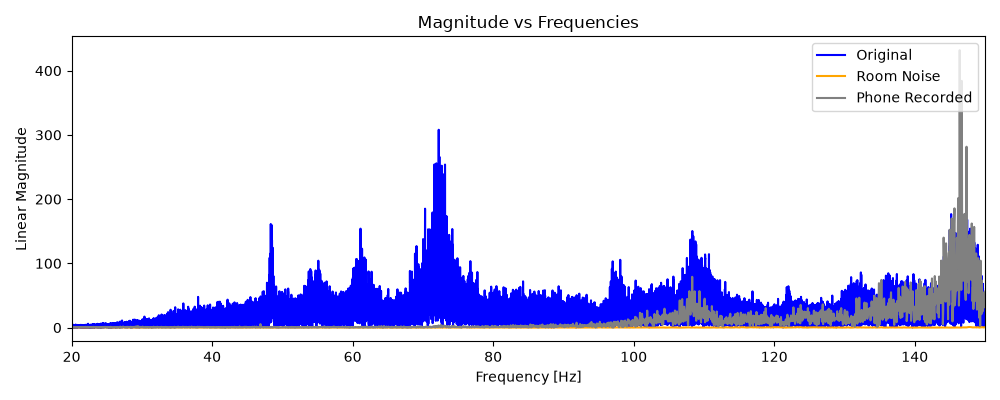

In [38]:
mono_data, f_transform, amplitude, f, sample_rate = transform_mono("come_together.wav")
room_data, room_f_transform, room_amplitude, room_f, room_sample_rate = transform_mono('room.wav')
phone_data, phone_f_transform, phone_amplitude, phone_f, phone_sample_rate = transform_mono('phone_recording.wav')
plot_freqs(f, amplitude, room_f, room_amplitude, phone_f, phone_amplitude, 'Magnitude vs Frequencies', 'Frequency [Hz]', 'Linear Magnitude')

C:\Users\eranm\AppData\Local\Temp\ipykernel_9812\4244724309.py:2: WavFileWarning: Reached EOF prematurely; finished at 45539519 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


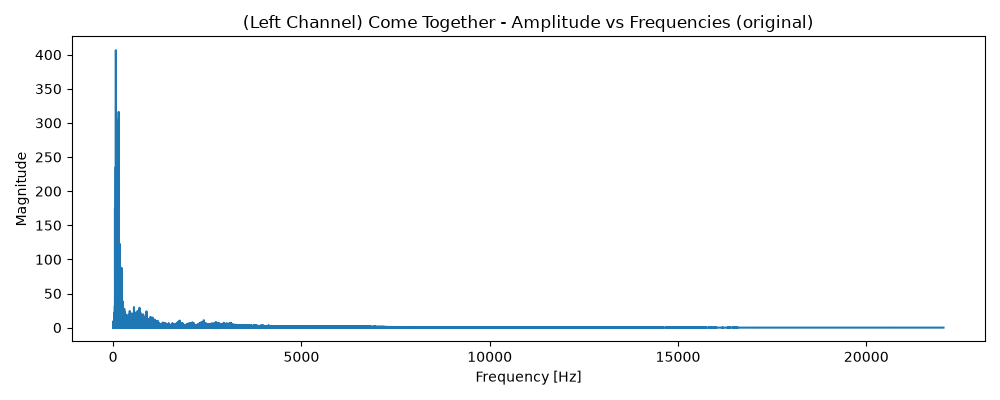

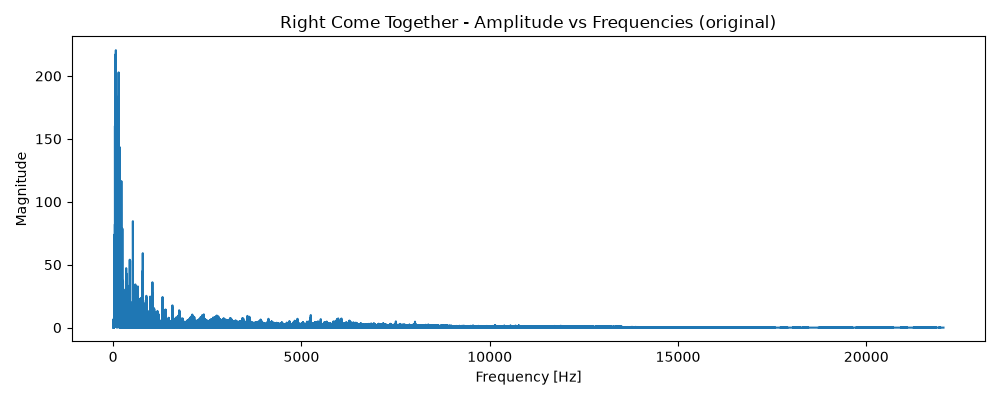

In [8]:
left_data, f_transform_left, amplitude_left, right_data, f_transform_right, amplitude_right, f, sample_rate = transform('come_together.wav')
plot(f, amplitude_left,  '(Left Channel) Come Together - Amplitude vs Frequencies (original)', 'Frequency [Hz]', 'Magnitude')
plot(f,  amplitude_right,  'Right Come Together - Amplitude vs Frequencies (original)', 'Frequency [Hz]', 'Magnitude')

In [9]:
def remove_dc_offset(f_transform):
    f_transform[0] = 0
    amplitude = np.abs(f_transform) / len(f_transform)
    return amplitude, f_transform

In [10]:
def adjust_to_speaker_freqs(sample_rate, f_transform):
    #35Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_freq_index = int(35/delta_f)+1
    # max_freq_index = int(20000/delta_f)+1

    f_transform[:min_freq_index] = 0
    #TBD, low pass filter
    # f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform

In [11]:
def adjust_to_iphone_freqs(sample_rate, f_transform):
    #200Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_freq_index = int(200/delta_f)+1
    # max_freq_index = int(16000/delta_f)+1
    
    f_transform[:min_freq_index] = 0
    # f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform

In [12]:
def amplify_frequencies(sample_rate, f_transform):
    #200Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_freq_index = int(200/delta_f)+1
    
    for i in range(min_freq_index):
        f_transform[i] *= 2
    # f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform

In [13]:
def missing_fundamental(sample_rate, f_transform):
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_audible_index = int(20/delta_f)+1
    min_freq_index = int(200/delta_f)+1
    for i in range(min_audible_index, min_freq_index):
        #minimum harmonic that is >= min_freq_index
        n = math.ceil(200/(i*delta_f))
        n_index = n*i
        n_p1_index = (n+1)*i
        n_p2_index = (n+2)*i
        
        f_transform[n_index] += (f_transform[i] / (n))
        f_transform[n_p1_index] += (f_transform[i] / ((n+1)))
        f_transform[n_p2_index] += (f_transform[i] / ((n+2)))

    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform


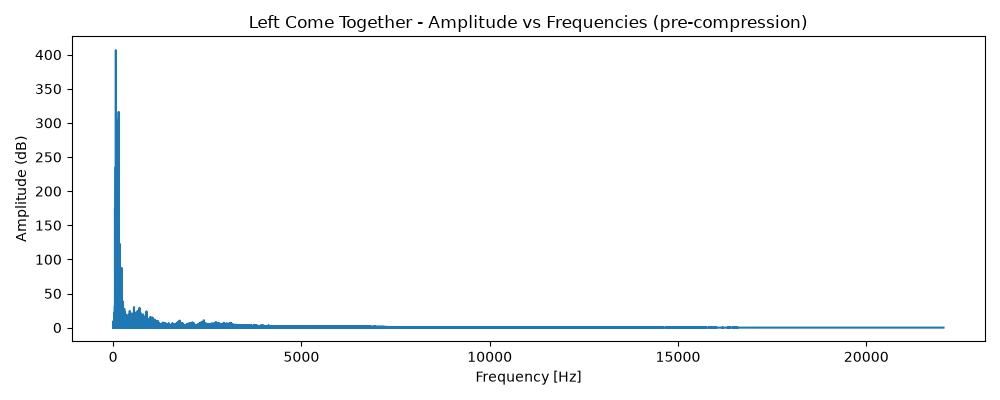

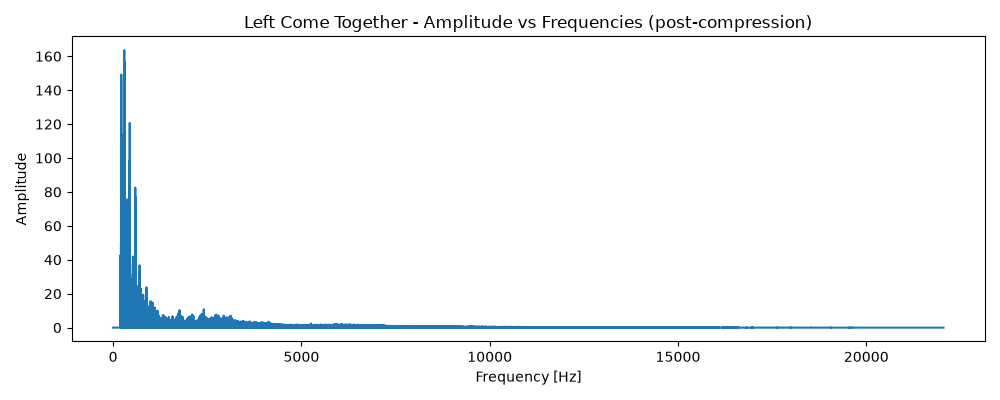

In [14]:
al, ftl = missing_fundamental(sample_rate, f_transform_left.copy())
ar, ftr = missing_fundamental(sample_rate, f_transform_right.copy())
amplitude_left_new, f_transform_left_new = adjust_to_iphone_freqs(sample_rate, ftl.copy())
amplitude_right_new, f_transform_right_new = adjust_to_iphone_freqs(sample_rate, ftr.copy())
# amplitude_left_new, f_transform_left_new= missing_fundamental(sample_rate, f_transform_left.copy())
# amplitude_right_new, f_transform_right_new = missing_fundamental(sample_rate, f_transform_right.copy())

plot(f, amplitude_left,  'Left Come Together - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')
plot(f, amplitude_left_new,  'Left Come Together - Amplitude vs Frequencies (post-compression)', 'Frequency [Hz]', 'Amplitude')

In [15]:
def inverse_transform(left, right, sample_rate, output_filename):
    reconstructed_left = irfft(left)
    reconstructed_right = irfft(right)
  
    reconstructed_real = np.stack((reconstructed_left, reconstructed_right), axis=1)
    audio_data_int16 = np.int16(np.clip(reconstructed_real, -32768, 32767))
    
    wavfile.write(output_filename, sample_rate, audio_data_int16)

    return audio_data_int16

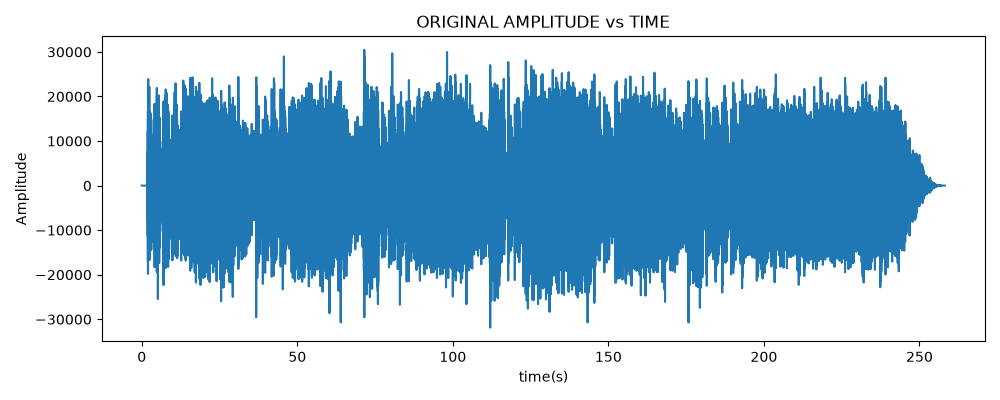

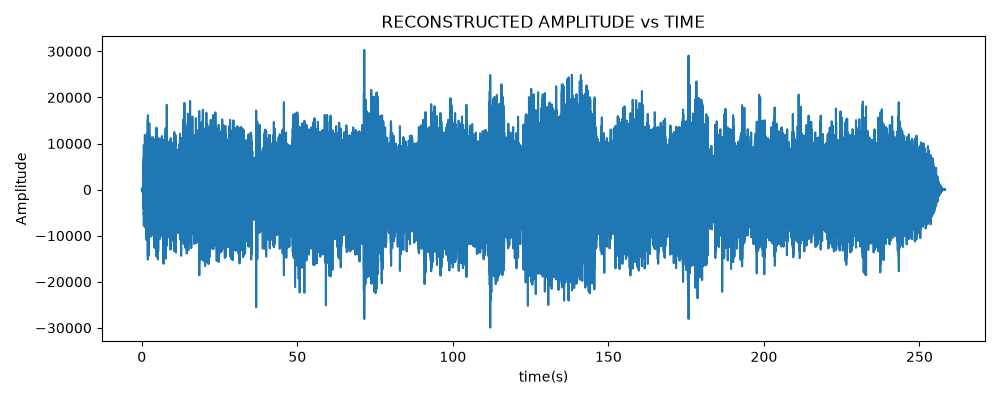

In [16]:
reconstructed_data = inverse_transform(f_transform_left_new, f_transform_right_new, sample_rate, 'come_together_with_harmonics.wav')
original_data = np.stack((left_data, right_data), axis=1)

# delta = reconstructed_data - original_data
# print(np.mean(np.abs(delta)))
# wavfile.write('delta.wav', sample_rate, delta)

reconstructed_ld = reconstructed_data[:, 0]

duration = len(original_data) / sample_rate
time = np.linspace(0.0, duration, num=len(original_data))

dbfs_ref = 32768.0
plot(time, left_data, 'ORIGINAL AMPLITUDE vs TIME', 'time(s)', 'Amplitude')
plot(time, reconstructed_ld, 'RECONSTRUCTED AMPLITUDE vs TIME', 'time(s)', 'Amplitude')